In [1]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Nikhil Bidkar\retail-analytics\bigquery_key.json"

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

client = bigquery.Client(project="retail-analytics-493018")
print("Connected!")

Connected!


In [2]:
# Load RFM data for clustering
query = """
WITH last_order_date AS (
    SELECT MAX(DATE(order_purchase_timestamp)) AS max_date
    FROM `retail-analytics-493018.olist_raw.orders`
),
rfm AS (
    SELECT
        o.customer_id,
        DATE_DIFF(l.max_date, MAX(DATE(o.order_purchase_timestamp)), DAY) AS recency,
        COUNT(o.order_id) AS frequency,
        ROUND(SUM(p.payment_value), 2) AS monetary
    FROM `retail-analytics-493018.olist_raw.orders` o
    JOIN `retail-analytics-493018.olist_raw.payments` p ON o.order_id = p.order_id
    CROSS JOIN last_order_date l
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id, l.max_date
)
SELECT * FROM rfm
"""

rfm = client.query(query).to_dataframe()

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

print("Data ready for clustering!")
print(rfm.shape)

C:\Users\Nikhil Bidkar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Data ready for clustering!
(96477, 4)


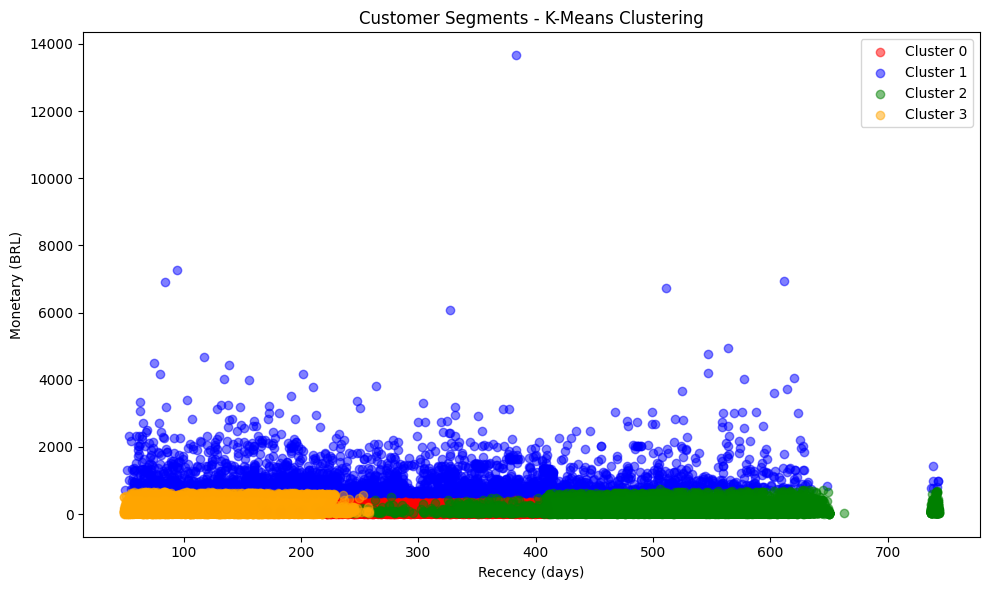

         recency  frequency  monetary
cluster                              
0         305.48       1.01    129.25
1         289.32       1.05   1099.10
2         505.97       1.11    131.24
3         136.84       1.04    136.16


In [3]:
# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Plot clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    cluster_data = rfm[rfm['cluster'] == i]
    plt.scatter(cluster_data['recency'], cluster_data['monetary'], 
                c=colors[i], label=f'Cluster {i}', alpha=0.5)

plt.xlabel('Recency (days)')
plt.ylabel('Monetary (BRL)')
plt.title('Customer Segments - K-Means Clustering')
plt.legend()
plt.tight_layout()
plt.show()

# Cluster summary
print(rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean().round(2))